In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Balancing a reactor whose products have no molecular formula (Illustrations 15.7-1 to 15.7-5, Tables 15.7-1 and 15.7-2)

$$1+Y_{N/S}C_N=Y_{B/S}+Y_{P/S}+Y_{C/S}\qquad
H_S+Y_{N/S}H_N+2Y_{W/S}=Y_{B/S}H_B+Y_{P/S}H_P$$
$$N_S+Y_{N/S}N_N=Y_{B/S}N_B+Y_{P/S}N_P\qquad
O_S+Y_{N/S}O_N+2Y_{O_2/S}+Y_{W/S}=2Y_{C/S}+Y_{B/S}O_B+Y_{P/S}O_P$$

A fermenter makes cells, and cells do not have a molecular formula. What they have is an elemental
analysis — Roels' "average biomass" is $\mathrm{CH_{1.8}O_{0.5}N_{0.2}}$, which is not a molecule and
never will be. So Sec. 15.7 does what the rest of the book does not: it balances **atoms** rather
than species, and it does the bookkeeping in *yield factors*, each one a ratio to the substrate
consumed.

That gives four linear equations in six yield factors. Fix any two and the other four follow, and
that is the whole of Illustrations 15.7-1 through 15.7-4. Illustration 15.7-5 adds the one estimate
that makes the *energy* balance possible when nothing about the biomass has been measured.

`thermo.bioreactor` assembles the four balances and solves them as a system rather than by hand
substitution, because each illustration fixes a different pair — and because the printed
substitutions are where this section's slips are.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.bioreactor import (CMole, Fermentation, from_table, c_mole_formula,
                               degree_of_reduction, regularity_G, regularity_H,
                               TABLE_15_7_2, TABLE_15_7_2_FORMULA,
                               TABLE_15_7_2_ORGANIC)
from thermo.charts import use_book_style

use_book_style()
os.makedirs("pdf", exist_ok=True)
FIG_W = 3.4

BIOMASS_ROELS = CMole("CH1.8O0.5N0.2", name="Roels average biomass")
print(BIOMASS_ROELS)

CMole(CH1.8O0.5N0.2 (Roels average biomass), xi = 4.8)


## Illustration 15.7-1 — a reported stoichiometry, and whether it closes

$$\mathrm{CO} + x\,\mathrm{O_2} + y\,\mathrm{N_2} + z\,\mathrm{H_2O}
\longrightarrow 0.52\,\mathrm{CO_2}+0.42\,\mathrm{CH_2O}+0.024\,\mathrm{CH_2O_{0.5}}
+0.036\ \text{C-mole cells}$$

*Methylotrophicum* on carbon monoxide, written on a C-mole basis: acetic acid
$\mathrm{CH_3COOH}$ becomes $0.42\,\mathrm{CH_2O}$ (two carbons, so its coefficient doubles) and
butyric acid becomes $0.024\,\mathrm{CH_2O_{0.5}}$ (four carbons). The illustration checks the carbon
balance first, and then solves N, H and O in that order.

The check is not decoration: the carbon balance is the **only** one of the four already closed by
the reported data, so if it fails there is nothing to solve.

In [3]:
print("  C-mole formulas from the molecular ones:")
for mol in ("CO", "CH3COOH", "C4H8O2", "CO2"):
    print(f"    {mol:10s} -> {c_mole_formula(mol)}")

products = {"CO2": 0.52, "acetic acid (as CH2O)": 0.42,
            "butyric acid (as CH2O0.5)": 0.024, "cells (as CH1.8O0.5N0.2)": 0.036}
print(f"\n  carbon balance: 1 = {' + '.join(f'{v:g}' for v in products.values())} = "
      f"{sum(products.values()):g}")
assert abs(sum(products.values()) - 1.0) < 1e-12

# Everything except CO2 is a "product" in the module's sense; CO2 is tracked by Y_C_S.
# Two products, so run the balance as two passes and add -- the balances are linear.
CO = CMole("CO", name="carbon monoxide")
acetic = CMole("CH2O", name="acetic acid, C-mole")
butyric = CMole("CH2O0.5", name="butyric acid, C-mole")
print(f"\n  xi(CO) = {CO.xi:g}   xi(acetic) = {acetic.xi:g}   "
      f"xi(butyric) = {butyric.xi:g}   xi(biomass) = {BIOMASS_ROELS.xi:g}")

# Atom balances written out directly, exactly as the illustration does them.
Y = dict(CO2=0.52, acetic=0.42, butyric=0.024, cells=0.036)
y_N2 = Y["cells"] * BIOMASS_ROELS.N / 2.0                       # N balance
z = (Y["acetic"] * acetic.H + Y["butyric"] * butyric.H
     + Y["cells"] * BIOMASS_ROELS.H) / 2.0                      # H balance
O_out = (2 * Y["CO2"] + Y["acetic"] * acetic.O + Y["butyric"] * butyric.O
         + Y["cells"] * BIOMASS_ROELS.O)
x = (O_out - CO.O - z) / 2.0                                    # O balance
print(f"\n  O-balance right-hand side  = {O_out:.4f}      printed 1.49")
print(f"  y (N2 consumed)            = {y_N2:.4f}      printed 0.0036")
print(f"  z (H2O consumed)           = {z:.4f}      printed 0.4764")
print(f"  x (O2 consumed)            = {x:.4f}      printed 0.0068")
for got, want in ((O_out, 1.49), (y_N2, 0.0036), (z, 0.4764), (x, 0.0068)):
    assert abs(got - want) < 5e-4, (got, want)

  C-mole formulas from the molecular ones:
    CO         -> CO
    CH3COOH    -> CH2O
    C4H8O2     -> CH2O0.5
    CO2        -> CO2

  carbon balance: 1 = 0.52 + 0.42 + 0.024 + 0.036 = 1

  xi(CO) = 2   xi(acetic) = 4   xi(butyric) = 5   xi(biomass) = 4.8

  O-balance right-hand side  = 1.4900      printed 1.49
  y (N2 consumed)            = 0.0036      printed 0.0036
  z (H2O consumed)           = 0.4764      printed 0.4764
  x (O2 consumed)            = 0.0068      printed 0.0068


## Illustration 15.7-2 and Table 15.7-1 — the yield factors

Table 15.7-1 is six definitions, not data. Every one is a ratio to *C-moles of substrate consumed*,
which is why the units of $Y_{O_2/S}$ and $Y_{W/S}$ are moles per C-mole while the rest are
dimensionless.

Note the sign convention Sec. 15.7 sets and then relies on: every yield factor is positive except
$Y_{W/S}$, which is **negative when water is produced**. The illustrations that follow all produce
water, so all of them carry a negative one — and the printed text of Illustrations 15.7-3 and 15.7-4
says "0.063 moles of water are produced" while the table entry reads $-0.063$, which is consistent
but reads as a contradiction if the convention is missed.

In [4]:
rows = [("Y_B/S", Y["cells"], "C-moles biomass per C-mole substrate"),
        ("Y_CH2O/S", Y["acetic"], "C-moles acetic acid"),
        ("Y_CH2O0.5/S", Y["butyric"], "C-moles butyric acid"),
        ("Y_N/S", 2 * y_N2, "moles of N atoms (as N2, 2y)"),
        ("Y_O2/S", x, "moles O2"),
        ("Y_C/S", Y["CO2"], "moles CO2"),
        ("Y_W/S", z, "moles water CONSUMED here, so positive")]
print(pd.DataFrame(rows, columns=["factor", "value", "meaning"])
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\n  Illustration 15.7-2 prints Y_B/S = 0.036, Y_CH2O/S = 0.42, "
      "Y_CH2O0.5/S = 0.024,")
print("  Y_N/S = 0.0036, Y_O2/S = 0.0068, Y_C/S = 0.52, Y_W/S = 0.4764")
print("\n  Y_N/S is printed as 0.0036, which is y (moles of N2), not the moles of")
print("  NITROGEN ATOMS -- Table 15.7-1 defines Y_N/S per C-mole of nitrogen SOURCE,")
print("  and molecular nitrogen carries two atoms. Both readings appear in the")
print("  section; Eq. 15.7-3's N_N2 = 2 is the one that closes the balance.")

     factor  value                                meaning
      Y_B/S 0.0360   C-moles biomass per C-mole substrate
   Y_CH2O/S 0.4200                    C-moles acetic acid
Y_CH2O0.5/S 0.0240                   C-moles butyric acid
      Y_N/S 0.0072           moles of N atoms (as N2, 2y)
     Y_O2/S 0.0068                               moles O2
      Y_C/S 0.5200                              moles CO2
      Y_W/S 0.4764 moles water CONSUMED here, so positive

  Illustration 15.7-2 prints Y_B/S = 0.036, Y_CH2O/S = 0.42, Y_CH2O0.5/S = 0.024,
  Y_N/S = 0.0036, Y_O2/S = 0.0068, Y_C/S = 0.52, Y_W/S = 0.4764

  Y_N/S is printed as 0.0036, which is y (moles of N2), not the moles of
  NITROGEN ATOMS -- Table 15.7-1 defines Y_N/S per C-mole of nitrogen SOURCE,
  and molecular nitrogen carries two atoms. Both readings appear in the
  section; Eq. 15.7-3's N_N2 = 2 is the one that closes the balance.


## Illustrations 15.7-3 and 15.7-4 — the same four balances, different pairs fixed

15.7-3: *Saccharomyces cerevisiae* on glucose, anaerobic, ammonia as the nitrogen source, ethanol as
the product, biomass $\mathrm{CH_{1.8}O_{0.5}N_{0.2}}$ at $Y_{B/S}=0.14$. Anaerobic means
$Y_{O_2/S}=0$, so two factors are fixed and four are open.

15.7-4: the same organism aerobically, with biomass $\mathrm{CH_{1.8}O_{0.56}N_{0.17}}$, and *both*
$Y_{B/S}$ and $Y_{P/S}$ fixed by the reported 4.26 C-moles of glucose per C-mole of yeast.

In [5]:
glucose = from_table("glucose")
ethanol = from_table("ethanol")
ammonia = from_table("ammonia")
print(f"  {glucose}\n  {ethanol}\n  {ammonia}")

# --- Illustration 15.7-3 -----------------------------------------------------
f3 = Fermentation(substrate=glucose, biomass=BIOMASS_ROELS,
                  nitrogen=ammonia, product=ethanol)
s3 = f3.solve(Y_B_S=0.14, Y_O2_S=0.0)
printed3 = dict(Y_P_S=0.569, Y_C_S=0.291, Y_W_S=-0.063, Y_N_S=0.028)
print("\n  Illustration 15.7-3")
for k, v in printed3.items():
    print(f"    {k:8s} = {s3[k]:+8.4f}   printed {v:+.3f}")
    assert abs(s3[k] - v) < 5e-4, (k, s3[k])
print(f"    1.707 = {s3['Y_P_S'] * 6 / 2:.3f} mol ethanol per mol glucose   printed 1.707")
print(f"    1.748 = {s3['Y_C_S'] * 6:.3f} mol CO2 per mol glucose           printed 1.748")

# --- Illustration 15.7-4 -----------------------------------------------------
yeast = CMole("CH1.8O0.56N0.17", name="S. cerevisiae, aerobic")
f4 = Fermentation(substrate=glucose, biomass=yeast, nitrogen=ammonia, product=ethanol)
s4 = f4.solve(Y_B_S=1 / 4.26, Y_P_S=1.92 / 4.26)
printed4 = dict(Y_C_S=0.3145, Y_N_S=0.0399, Y_W_S=-0.1725, Y_O2_S=0.07923)
print("\n  Illustration 15.7-4")
for k, v in printed4.items():
    print(f"    {k:8s} = {s4[k]:+9.5f}   printed {v:+.5f}")
    assert abs(s4[k] - v) < 1e-4, (k, s4[k])
print(f"    Eq. 15.7-12 route to Y_O2/S: "
      f"{f4.Y_O2_from_xi(s4['Y_B_S'], s4['Y_P_S'], s4['Y_N_S']):.5f}  -- same number, "
      f"and it never needed the substrate's H and O")

  CMole(CH2O (glucose), xi = 4)
  CMole(CH3O0.5 (ethanol), xi = 6)
  CMole(NH3 (ammonia), xi = 3)

  Illustration 15.7-3
    Y_P_S    =  +0.5687   printed +0.569
    Y_C_S    =  +0.2913   printed +0.291
    Y_W_S    =  -0.0630   printed -0.063
    Y_N_S    =  +0.0280   printed +0.028
    1.707 = 1.706 mol ethanol per mol glucose   printed 1.707
    1.748 = 1.748 mol CO2 per mol glucose           printed 1.748

  Illustration 15.7-4
    Y_C_S    =  +0.31455   printed +0.31450
    Y_N_S    =  +0.03991   printed +0.03990
    Y_W_S    =  -0.17254   printed -0.17250
    Y_O2_S   =  +0.07923   printed +0.07923
    Eq. 15.7-12 route to Y_O2/S: 0.07923  -- same number, and it never needed the substrate's H and O


### Three printed slips the solve makes visible

Illustration 15.7-4 as printed sets its oxygen balance as

$$1 + 2Y_{W/S} + Y_{W/S} = 2Y_{C/S}+0.56\,Y_{B/S}+0.5\,Y_{P/S}$$

with $Y_{W/S}$ in the slot where $Y_{O_2/S}$ belongs. Its answers are nevertheless right, which means
the arithmetic behind them used the correct balance — Eq. 15.7-4, $1+2Y_{O_2/S}+Y_{W/S}=\dots$ The
cell below solves both forms and shows that the printed one does not reproduce the printed answers.

Two smaller ones in the same illustration: the ammonia line repeats the carbon dioxide line's
"1.748 ( = 0.291 × 6)", where the ammonia number is $0.0399\times6=0.239$; and $Y_{O_2/S}$ is given
as 0.07923 and then restated in the same sentence as 0.00792.

In [6]:
# Solve the printed oxygen balance instead of Eq. 15.7-4, holding everything else.
YB, YP = 1 / 4.26, 1.92 / 4.26
YN = yeast.N * YB
YC = 1.0 - YB - YP
YW_H = (yeast.H * YB + ethanol.H * YP - glucose.H - ammonia.H * YN) / 2.0
YO_correct = (2 * YC + yeast.O * YB + ethanol.O * YP - glucose.O - YW_H) / 2.0
# printed: 1 + 2 Y_W + Y_W = 2 Y_C + 0.56 Y_B + 0.5 Y_P, i.e. no oxygen term at all
lhs_printed = 1.0 + 3.0 * YW_H
rhs = 2 * YC + yeast.O * YB + 0.5 * YP
print(f"  Eq. 15.7-4 as derived:   Y_O2/S = {YO_correct:.5f}      printed answer 0.07923")
print(f"  the printed balance:     LHS = {lhs_printed:.5f}   RHS = {rhs:.5f}   "
      f"residual {lhs_printed - rhs:+.5f}")
print("  -- it does not close, and it contains no oxygen term to close it with.")
print()
print(f"  ammonia per mole of glucose: {YN * 6:.3f}      printed '1.748 ( = 0.291 x 6)'")
print(f"  Y_O2/S restated in the same sentence as 0.00792, against {YO_correct:.5f}")
print(f"  O2 per C-mole of yeast: {YO_correct * 4.26:.4f}      "
      f"printed 0.3375, measured 'about 0.35'")

  Eq. 15.7-4 as derived:   Y_O2/S = 0.07923      printed answer 0.07923
  the printed balance:     LHS = 0.48239   RHS = 0.98592   residual -0.50352
  -- it does not close, and it contains no oxygen term to close it with.

  ammonia per mole of glucose: 0.239      printed '1.748 ( = 0.291 x 6)'
  Y_O2/S restated in the same sentence as 0.00792, against 0.07923
  O2 per C-mole of yeast: 0.3375      printed 0.3375, measured 'about 0.35'


## Illustration 15.7-2's other half — a substrate you know nothing about

If the substrate's hydrogen and oxygen contents are unknown, only two of the balances survive:
carbon ($Y_{B/S}=1-Y_{C/S}$) and nitrogen ($Y_{B/S}=5Y_{N/S}$ for the Roels biomass). The module
refuses that case rather than returning one of the infinitely many solutions, which is the
behavior Sec. 15.7 describes in words.

In [7]:
unknown = CMole("C", name="unspecified nonnitrogenous substrate")
f_unknown = Fermentation(substrate=unknown, biomass=BIOMASS_ROELS, nitrogen=ammonia)
try:
    f_unknown.solve(Y_B_S=0.3, Y_O2_S=0.0)
except Exception as exc:
    print(f"  {type(exc).__name__}: {exc}")
print()
print("  what CAN be said, from the two surviving balances:")
for YB in (0.2, 0.4, 0.6):
    print(f"    Y_B/S = {YB:.1f}  ->  Y_C/S = {1 - YB:.1f},  "
          f"Y_N/S = {YB * BIOMASS_ROELS.N:.3f}  (5 C-moles biomass per mole ammonia)")

  ValueError: four balances determine four unknowns; 3 are open (['Y_C_S', 'Y_N_S', 'Y_W_S']). Fix or free one and try again.

  what CAN be said, from the two surviving balances:
    Y_B/S = 0.2  ->  Y_C/S = 0.8,  Y_N/S = 0.040  (5 C-moles biomass per mole ammonia)
    Y_B/S = 0.4  ->  Y_C/S = 0.6,  Y_N/S = 0.080  (5 C-moles biomass per mole ammonia)
    Y_B/S = 0.6  ->  Y_C/S = 0.4,  Y_N/S = 0.120  (5 C-moles biomass per mole ammonia)


## Illustration 15.7-5 and Table 15.7-2 — the estimate that unlocks the energy balance

$$\xi_i=\frac{4C_i+H_i-2O_i}{C_i}\qquad
\Delta_cG\approx 112\,\xi\ \ \frac{\text{kJ}}{\text{C-mole}},\qquad
\Delta_cH\approx 110.9\,\xi\ \ \frac{\text{kJ}}{\text{C-mole}}$$

Nobody has put average biomass in a bomb calorimeter, so its heat of combustion has to be estimated
— and Eqs. 15.7-10 do it from the elemental analysis alone. That is what makes the whole energy
balance of the next notebook possible.

Table 15.7-2 is where those two constants come from. **Its last two columns are derived**, so every
row checks itself: $\Delta_cG/\xi$ and $\Delta_cH/\xi$ follow from the two columns to their left, and
$\xi$ itself follows from the compound's formula. That is three independent checks per row, and it
is the same contract Table 14.6-1 is under.

In [8]:
rows = []
for name, (xi_printed, dcG, dcH) in TABLE_15_7_2.items():
    c = from_table(name)                      # raises if xi disagrees with the formula
    rows.append((name, TABLE_15_7_2_FORMULA[name], c_mole_formula(TABLE_15_7_2_FORMULA[name]),
                 xi_printed, c.xi, dcG, dcH, dcG / c.xi, dcH / c.xi))
tab = pd.DataFrame(rows, columns=["compound", "formula", "per C-mole", "xi printed",
                                  "xi from formula", "dcG", "dcH", "dcG/xi", "dcH/xi"])
print(f"  {len(tab)} rows, and every xi regenerated from its formula agrees with the")
print(f"  printed column to {np.max(np.abs(tab['xi printed'] - tab['xi from formula'])):.4f}")
print()
print(tab.head(14).to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print("  ...")

  53 rows, and every xi regenerated from its formula agrees with the
  printed column to 0.0050

      compound  formula         per C-mole  xi printed  xi from formula   dcG   dcH  dcG/xi  dcH/xi
   acetic acid   C2H4O2               CH2O           4                4   447   438   111.8   109.5
propionic acid   C3H6O2       CH2O0.666667        4.67            4.667   511 509.7   109.5   109.2
  butyric acid   C4H8O2            CH2O0.5           5                5 543.3 548.5   108.7   109.7
  valeric acid  C5H10O2            CH2O0.4         5.2              5.2 562.6 568.2   108.2   109.3
 palmitic acid C16H32O2          CH2O0.125        5.75             5.75 612.5 624.3   106.5   108.6
   lactic acid   C3H6O3               CH2O           4                4   459 456.3   114.8   114.1
   oxalic acid   C2H2O4               CHO2           1                1 163.5   123   163.5     123
 succinic acid   C4H6O4             CH1.5O         3.5              3.5 399.8 373.3   114.2   106.7
  f

In [9]:
organic = tab[tab["compound"].isin(TABLE_15_7_2_ORGANIC)]
print(f"  organic rows (above the rule in the printed table): {len(organic)}")
print(f"  mean dcG/xi = {organic['dcG/xi'].mean():.2f}      printed Average 112.0")
print(f"  mean dcH/xi = {organic['dcH/xi'].mean():.2f}      printed Average 110.9")
print()
print(f"  with the seven 'Other compounds' included instead:")
print(f"  mean dcG/xi = {tab['dcG/xi'].mean():.2f}   mean dcH/xi = {tab['dcH/xi'].mean():.2f}")
print()
print("  Neither pairing gives 112.0 and 110.9 exactly. Over the organics -- which is")
print("  the set the rule in the middle of the printed table marks off -- the two")
print(f"  means are {organic['dcG/xi'].mean():.2f} and {organic['dcH/xi'].mean():.2f}, so the printed averages are each")
print("  rounded UP by one in the last digit: 111.9 and 110.8 are what the columns say.")
print("  The 112 and 110.9 of Eq. 15.7-10 are used everywhere in Sec. 15.7 and in this")
print("  notebook, so this is a note about the table, not a change to make.")
print()
worst = organic.reindex(
    (organic["dcH/xi"] - organic["dcH/xi"].mean()).abs().sort_values().index)
print("  the five rows furthest from the regularity line (dcH):")
print(worst.tail(5)[["compound", "xi from formula", "dcH", "dcH/xi"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4g}"))

  organic rows (above the rule in the printed table): 46
  mean dcG/xi = 111.94      printed Average 112.0
  mean dcH/xi = 110.78      printed Average 110.9

  with the seven 'Other compounds' included instead:
  mean dcG/xi = 111.75   mean dcH/xi = 110.98

  Neither pairing gives 112.0 and 110.9 exactly. Over the organics -- which is
  the set the rule in the middle of the printed table marks off -- the two
  means are 111.94 and 110.78, so the printed averages are each
  rounded UP by one in the last digit: 111.9 and 110.8 are what the columns say.
  The 112 and 110.9 of Eq. 15.7-10 are used everywhere in Sec. 15.7 and in this
  notebook, so this is a note about the table, not a change to make.

  the five rows furthest from the regularity line (dcH):
       compound  xi from formula   dcH  dcH/xi
        glucose                4 467.8     117
       glucitol            4.333 508.2   117.3
ethylene glycol                5 590.5   118.1
       glycerol            4.667 554.3   118.8
 

  xi(CH1.8O0.5N0.2) = (4 x 1 + 1.8 - 2 x 0.5)/1 = 4.8      printed 4.8
  dcG = 112   x 4.8 = 537.6 kJ/C-mole   printed 537.6
  dcH = 110.9 x 4.8 = 532.3 kJ/C-mole   printed 532.3



  scatter about the regularity line: rms 14.6 kJ/C-mole, worst 36.8
  glucose alone is off by 24.2 kJ/C-mole, which is the discrepancy Illustration
  15.7-6's Note traces its own 16 kJ disagreement to


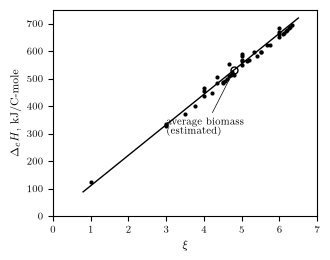

In [10]:
# Illustration 15.7-5 itself.
xi_B = BIOMASS_ROELS.xi
print(f"  xi(CH1.8O0.5N0.2) = (4 x 1 + 1.8 - 2 x 0.5)/1 = {xi_B:g}      printed 4.8")
print(f"  dcG = 112   x {xi_B:g} = {float(regularity_G(xi_B)):.1f} kJ/C-mole   printed 537.6")
print(f"  dcH = 110.9 x {xi_B:g} = {float(regularity_H(xi_B)):.1f} kJ/C-mole   printed 532.3")
assert abs(float(regularity_G(xi_B)) - 537.6) < 0.05
assert abs(float(regularity_H(xi_B)) - 532.3) < 0.05

fig, ax = plt.subplots(figsize=(FIG_W, 2.7))
ax.plot(organic["xi from formula"], organic["dcH"], "k.", ms=4)
xs = np.linspace(0.8, 6.5, 50)
ax.plot(xs, 110.9 * xs, "k", lw=1.0)
ax.plot([xi_B], [float(regularity_H(xi_B))], "ko", ms=5, mfc="none")
ax.annotate("average biomass\n(estimated)", xy=(xi_B, float(regularity_H(xi_B))),
            xytext=(3.0, 300), fontsize=7,
            arrowprops=dict(arrowstyle="-", lw=0.5))
ax.set_xlabel(r"$\xi$", fontsize=8)
ax.set_ylabel(r"$\Delta_cH$, kJ/C-mole", fontsize=8)
ax.set_xlim(0, 7)
ax.set_ylim(0, 750)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf_regularity.pdf", dpi=300, bbox_inches="tight")
resid = organic["dcH"] - 110.9 * organic["xi from formula"]
print(f"\n  scatter about the regularity line: rms {np.sqrt((resid ** 2).mean()):.1f} "
      f"kJ/C-mole, worst {resid.abs().max():.1f}")
print(f"  glucose alone is off by "
      f"{467.8 - 110.9 * 4:.1f} kJ/C-mole, which is the discrepancy Illustration")
print("  15.7-6's Note traces its own 16 kJ disagreement to")

## What came out of this

| target | here | printed |
|---|---|---|
| 15.7-1, O-balance right side | 1.4900 | 1.49 |
| 15.7-1, $x$, $y$, $z$ | 0.0068, 0.0036, 0.4764 | same |
| 15.7-3, $Y_{P/S}$, $Y_{C/S}$, $Y_{W/S}$, $Y_{N/S}$ | 0.5687, 0.2913, $-0.0630$, 0.0280 | 0.569, 0.291, $-0.063$, 0.028 |
| 15.7-4, $Y_{C/S}$, $Y_{N/S}$, $Y_{W/S}$, $Y_{O_2/S}$ | 0.31455, 0.03991, $-0.17254$, 0.07923 | same to the printed digits |
| 15.7-4, Eq. 15.7-12 route to $Y_{O_2/S}$ | identical | "two different but equivalent ways" |
| 15.7-5, $\xi$, $\Delta_cG$, $\Delta_cH$ | 4.8, 537.6, 532.3 | same |
| Table 15.7-2, $\xi$ regenerated from the formula | **53 of 53 agree** | — |
| Table 15.7-2, mean $\Delta_cG/\xi$ over the organics | 111.94 | 112.0 (rounds to 111.9) |
| Table 15.7-2, mean $\Delta_cH/\xi$ over the organics | 110.78 | 110.9 (rounds to 110.8) |

Table 15.7-2 comes through clean — all 53 degrees of reduction regenerate from the compounds'
formulas. Record it, because Table 14.6-1, checked the same way one chapter earlier, had four bad cells. The `Average` line at the foot of the table is a tenth of a unit high
in both columns (111.94 and 110.78 against the printed 112.0 and 110.9), but Eq. 15.7-10's constants
are used as 112 and 110.9 throughout the section, so that is a note rather than a change.

What does not come through clean is **Illustration 15.7-4's oxygen balance**, printed as
$1+2Y_{W/S}+Y_{W/S}=\dots$ with no oxygen term in it. The illustration's answers are right, so the
defect is in the typesetting of the balance rather than in the calculation behind it — but as printed
the equation cannot be solved for the number that follows it. The same illustration repeats the
carbon dioxide result on the ammonia line, and restates $Y_{O_2/S}=0.07923$ as 0.00792 one clause
later.

## Your turn

1. Illustration 15.7-1 solves N, then H, then O. Show that the order is forced — that neither the
   hydrogen nor the oxygen balance can be solved first — and then find a reported stoichiometry for
   which the order would be different. What feature of the reaction decides it?
2. `Fermentation.solve` refuses a problem with three or five unknowns. For the anaerobic case of
   Illustration 15.7-3, work out *which* pairs of the six yield factors are legitimate to fix, and
   which pairs leave the system singular. Explain the singular ones physically.
3. Repeat Illustration 15.7-3 with the aerobic biomass $\mathrm{CH_{1.8}O_{0.56}N_{0.17}}$ in place
   of the Roels average. How much do the four answers move? Use it to say how precisely the
   elemental analysis of the cells has to be known before it limits the answer.
4. Regenerate Table 15.7-2's two right-hand columns and find the rows where the printed ratio
   differs from $\Delta_cG/\xi$ by more than 0.1. Are they transcription errors, or rounding of a
   value that was itself rounded? Distinguish the two cases by looking at how many digits each row
   carries.
5. Eq. 15.7-10's constants are averages over the 46 organics. Refit them over just the amino acids,
   and then over just the alkanes. How different are the two, and what does the difference imply
   about using 110.9 for a biomass, which is mostly protein?
6. The generalized degree of reduction used here gives $\xi=3$ for ammonia and $\xi=0$ for
   N$_2$. Another common definition assigns nitrogen a valence of $-3$, which makes $\xi(\rm NH_3)=0$.
   Redo Illustration 15.7-4's Eq. 15.7-12 route under that definition and show what else would have
   to change for the answer to stay the same.